In [1]:
!pip install -q transformers datasets seaborn

Datasets for roman urdu sentiment analysis from hugging face:
* *Aimlab/Sentiment-Analysis-Roman-Urdu*
* **HowMannyMore/romanurdu-sentiment-dataset**
* ayeshasameer/roman-urdu-sentiment-analysis
* mteb/urdu_roman_sentiment
* talhafewfefefew/Roman-Urdu-sentiment
* talhafewfefefew/Roman-Urdu-sentiment-1
* Khubaib01/roman-urdu-sentiment-embeddings

from datasets import load_dataset

ds = load_dataset("User/Dataset")

In [3]:
# Import Libraries

## standard
import numpy as np
import pandas as pd

## plot
import seaborn as sns
import matplotlib.pyplot as plt

## huggingface dataset
from datasets import load_dataset

In [4]:
ds = load_dataset("HowMannyMore/romanurdu-sentiment-dataset")

print(ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/511 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.71M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/765k [00:00<?, ?B/s]

data/valid-00000-of-00001.parquet:   0%|          | 0.00/661k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60190 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12497 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/10622 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 60190
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12497
    })
    valid: Dataset({
        features: ['text', 'label'],
        num_rows: 10622
    })
})


In [6]:
df = ds['train'].to_pandas()
print(df.shape)
print(df.head())
print(df.dtypes)

(60190, 2)
                                                text     label
0  namoona word bolungi unhe ek ghoori deni mujhe...  Negative
1  sir ya kitni month ya years work kra gi?? btw ...  Positive
2                      bhot acha ha shekk bhot umda   Positive
3  mashaalla give wisdom to our muslims afghan br...   Neutral
4  hazrat sahab salam mari wife bohat beemar hai ...   Neutral
text     object
label    object
dtype: object


In [7]:
print(df.isnull().sum()) # no null values

text     0
label    0
dtype: int64


In [9]:
print(df["label"].value_counts())

label
Neutral     20247
Negative    20018
Positive    19925
Name: count, dtype: int64


/tmp/ipykernel_613/3992365506.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", palette="viridis")


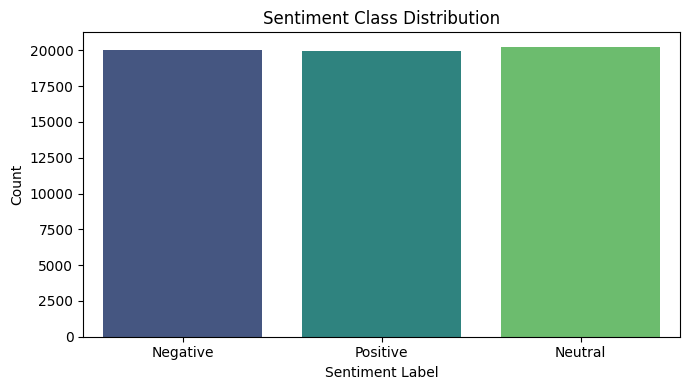

In [10]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="label", palette="viridis")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

In [12]:
df["text_length"] = df["text"].apply(len)

print(df["text_length"].describe())

count    60190.000000
mean        74.942532
std         84.129288
min          0.000000
25%         29.000000
50%         48.000000
75%         92.000000
max       2403.000000
Name: text_length, dtype: float64


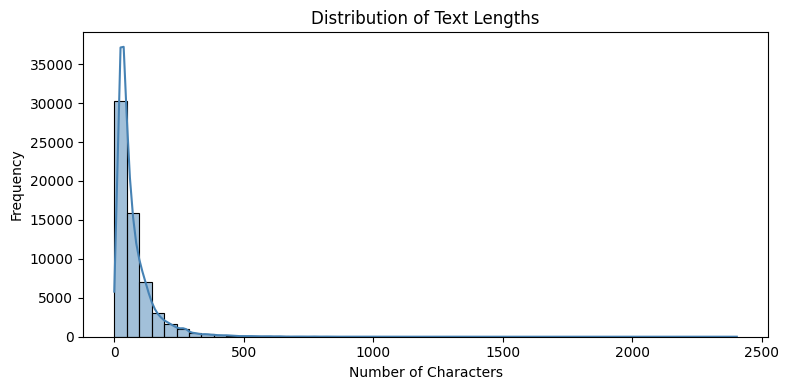

In [13]:
plt.figure(figsize=(8, 4))
sns.histplot(df["text_length"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Text Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("text_length_distribution.png", dpi=150)
plt.show()

/tmp/ipykernel_613/3548559418.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y="text_length", palette="viridis")


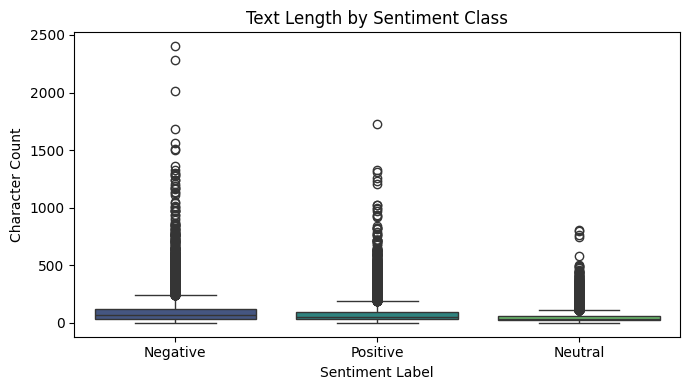

In [14]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="label", y="text_length", palette="viridis")
plt.title("Text Length by Sentiment Class")
plt.xlabel("Sentiment Label")
plt.ylabel("Character Count")
plt.tight_layout()
plt.savefig("length_by_class.png", dpi=150)
plt.show()

In [15]:
print("EDA complete.")
print("Total samples:", len(df))
print("Columns:", df.columns.tolist())

EDA complete.
Total samples: 60190
Columns: ['text', 'label', 'text_length']
